# 07 — NQS Comparison (NetKet)

> **spinq-vqe** | ARPA Quantum Logical Systems (QONDRA)

ED is exact but exponential. DMRG (NB06) is the polynomial MPS reference.
Reviewers also ask for a **Neural Quantum State** baseline: a neural-network
wavefunction optimized with Variational Monte Carlo (Carleo & Troyer 2017).

This notebook builds that baseline with [NetKet](https://www.netket.org/)
on the **same** Kagome-strip Hamiltonian as NB01–NB06, then places NQS beside
ED, DMRG, and VQE.

**Install:** `pip install -e ".[nqs]"`  
**Regenerate committed artifacts:** `python scripts/run_nqs_benchmark.py`

## What this establishes

| Check | Purpose |
|-------|---------|
| Hamiltonian match | NetKet reproduces the PennyLane ED matrix |
| Complex RBM | Recovers ED to ≪5% at N=9 (exact full-summation VMC) |
| RBMModPhase | Amplitude–phase factorization as a second architecture |
| Real RBM control | Shows why complex parameters are required on this strip |
| Four-way table | ED / DMRG / NQS / VQE on identical normalized energies |

### Scientific notes

- **Append-only figures:** this notebook writes `nqs_*.png` and
  `method_comparison.csv`. It does **not** overwrite DMRG or scaling figures.
- **Strip, not 2D Kagome:** we do not claim literature 2D Kagome GCNN accuracies.
  A strip-adapted GCNN underperformed here; RBMModPhase is the honest second model.
- **Exact vs sampled:** for N≤12 we use NetKet `FullSumState` (no MC noise).
  Sampled VMC is reserved for larger N.

### References
- Carleo & Troyer (2017) Science 355 — Neural Quantum States
- Đurić et al. (2025) PRX 15 — GCNN NQS on Kagome Heisenberg
- Vieijra et al. (2020) PRL 124 — symmetry-adapted RBM


In [1]:
from __future__ import annotations
import os
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from spinq_vqe import nqs

os.makedirs('../figures', exist_ok=True)
os.makedirs('../data', exist_ok=True)

REPO = Path('..').resolve()
DATA = REPO / 'data'
FIG = REPO / 'figures'

ED_N9 = -1.4219039949999581
print('NetKet available:', nqs.NETKET_AVAILABLE)


NetKet available: True


---
## 1. Validate Hamiltonian against PennyLane ED

Same contract as TeNPy in NB06: one XX+YY+ZZ term per `kagome_graph` edge at
`J/(4N)`, plus the global `D/4` identity shift.


In [2]:
max_diff = nqs.validate_hamiltonian_against_pennylane(3)
print(f'max |H_netket - H_pennylane| at N=9: {max_diff:.3e}')
assert max_diff < 1e-10


max |H_netket - H_pennylane| at N=9: 0.000e+00


---
## 2. Why complex parameters matter

A real-valued RBM cannot encode the frustrated Kagome sign structure and
plateaus far above E₀. Complex RBM (or RBMModPhase) recovers the ground state.
This is a short diagnostic — production numbers come from the benchmark script
(400 iterations, exact full-summation).


In [3]:
real = nqs.run_nqs(
    3, model='rbm', n_iter=80, alpha=2.0, learning_rate=0.05,
    backend='exact', complex_params=False, optimizer='sgd', seed=42,
)
cplx = nqs.run_nqs(
    3, model='rbm', n_iter=300, alpha=2.0, learning_rate=0.01,
    backend='exact', complex_params=True, optimizer='adam', seed=42,
)

def err(e):
    return abs(e - ED_N9) / abs(ED_N9) * 100

print(f'Real RBM:     E0={real.e0:.6f}  err={err(real.e0):.2f}%')
print(f'Complex RBM:  E0={cplx.e0:.6f}  err={err(cplx.e0):.4f}%')
print(f'ED:           E0={ED_N9:.6f}')


Real RBM:     E0=-0.164959  err=88.40%
Complex RBM:  E0=-1.415127  err=0.4766%
ED:           E0=-1.421904


---
## 3. Method comparison table

Load committed `data/method_comparison.csv` (regenerate with the benchmark script).
VQE best energies come from NB02/NB05; DMRG from NB06.


In [4]:
csv_path = DATA / 'method_comparison.csv'
if not csv_path.exists():
    raise FileNotFoundError(
        'Missing data/method_comparison.csv — run: python scripts/run_nqs_benchmark.py'
    )

df = pd.read_csv(csv_path)
display_cols = [
    'n_sites', 'E_ED', 'E_DMRG', 'E_NQS_RBM', 'E_NQS_MODPHASE', 'E_VQE',
    'NQS_RBM_error_vs_ED_pct', 'NQS_MODPHASE_error_vs_ED_pct', 'VQE_error_vs_ED_pct',
]
print(df[display_cols].to_string(index=False))


 n_sites  n_cells      E_ED    E_DMRG  E_NQS_RBM  E_NQS_RBM_err  E_NQS_MODPHASE  E_NQS_MODPHASE_err     E_VQE  NQS_RBM_error_vs_ED_pct  NQS_MODPHASE_error_vs_ED_pct  VQE_error_vs_ED_pct NQS_backend
       9        3 -1.421904 -1.421904  -1.421831            0.0       -1.421812                 0.0 -1.284563                   0.0051                        0.0064               9.6589       exact
      12        4 -1.480418 -1.480418  -1.480155            0.0       -1.450947                 0.0 -1.238595                   0.0178                        1.9907              16.3348       exact


---
## 4. Convergence figure (N=9)

Exact full-summation VMC histories from the benchmark (`data/nqs_*_history_n9.csv`).

→ Saved to `figures/nqs_vmc_convergence.png`


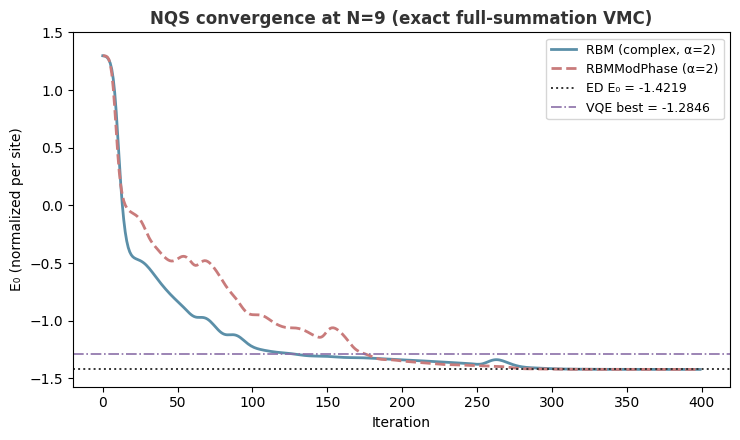

In [5]:
rbm_h = np.loadtxt(DATA / 'nqs_rbm_history_n9.csv', delimiter=',', skiprows=1)
mod_h = np.loadtxt(DATA / 'nqs_modphase_history_n9.csv', delimiter=',', skiprows=1)
vqe9 = float(df.loc[df['n_sites'] == 9, 'E_VQE'].iloc[0])
ed9 = float(df.loc[df['n_sites'] == 9, 'E_ED'].iloc[0])

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(rbm_h, color='#5B8FA8', lw=2, label='RBM (complex, α=2)')
ax.plot(mod_h, color='#C97B7B', lw=2, ls='--', label='RBMModPhase (α=2)')
ax.axhline(ed9, color='#333333', ls=':', lw=1.4, label=f'ED E₀ = {ed9:.4f}')
ax.axhline(vqe9, color='#8B6FA8', ls='-.', lw=1.2, label=f'VQE best = {vqe9:.4f}')
ax.set_xlabel('Iteration')
ax.set_ylabel('E₀ (normalized per site)')
ax.set_title('NQS convergence at N=9 (exact full-summation VMC)', fontweight='semibold', color='#333')
ax.legend(fontsize=9)
ax.set_ylim(min(ed9, rbm_h.min(), mod_h.min()) - 0.15, 1.5)
plt.tight_layout()
plt.savefig(FIG / 'nqs_vmc_convergence.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 5. Four-way energy comparison

ED / DMRG / NQS / VQE on the same normalized energies (append-only figure).

→ Saved to `figures/nqs_method_comparison.png`


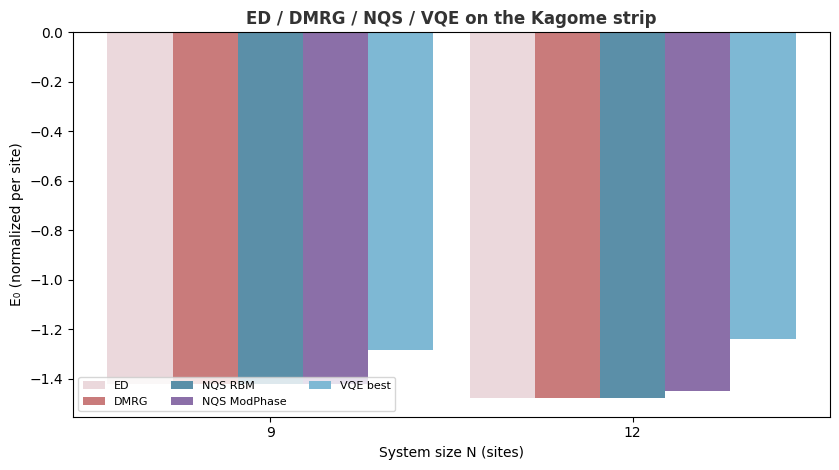

In [6]:
sizes = df['n_sites'].tolist()
x = np.arange(len(sizes))
width = 0.18
series = [
    (df['E_ED'].to_numpy(), 'ED', '#EBD8DC'),
    (df['E_DMRG'].to_numpy(), 'DMRG', '#C97B7B'),
    (df['E_NQS_RBM'].to_numpy(), 'NQS RBM', '#5B8FA8'),
    (df['E_NQS_MODPHASE'].to_numpy(), 'NQS ModPhase', '#8B6FA8'),
    (df['E_VQE'].to_numpy(), 'VQE best', '#7EB8D4'),
]
offsets = np.linspace(-(len(series) - 1) / 2, (len(series) - 1) / 2, len(series))

fig, ax = plt.subplots(figsize=(8.5, 4.8))
for (vals, label, color), off in zip(series, offsets):
    ax.bar(x + off * width, vals, width, label=label, color=color)
ax.set_xticks(x, [str(n) for n in sizes])
ax.set_xlabel('System size N (sites)')
ax.set_ylabel('E₀ (normalized per site)')
ax.set_title('ED / DMRG / NQS / VQE on the Kagome strip', fontweight='semibold', color='#333')
ax.legend(fontsize=8, ncol=3)
plt.tight_layout()
plt.savefig(FIG / 'nqs_method_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 6. Relative error vs ED

Log-scale gap between classical NQS and VQE (same ED reference).

→ Saved to `figures/nqs_error_vs_ed.png`


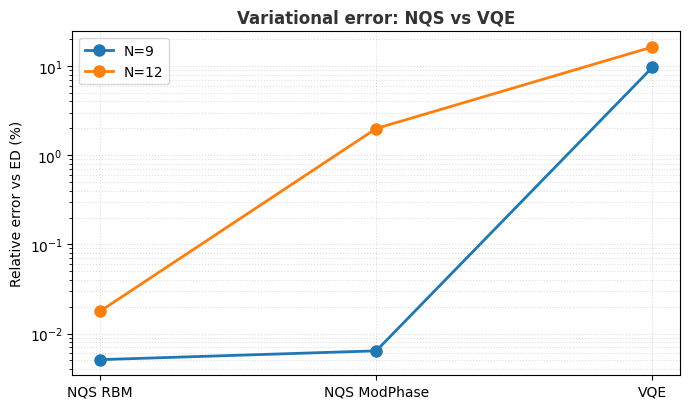

Regenerate all NB07 figures via: python scripts/run_nqs_benchmark.py


In [7]:
fig, ax = plt.subplots(figsize=(7, 4.2))
for _, row in df.iterrows():
    n = int(row['n_sites'])
    xs = ['NQS RBM', 'NQS ModPhase', 'VQE']
    ys = [
        float(row['NQS_RBM_error_vs_ED_pct']),
        float(row['NQS_MODPHASE_error_vs_ED_pct']),
        float(row['VQE_error_vs_ED_pct']),
    ]
    ax.plot(xs, ys, 'o-', lw=2, ms=8, label=f'N={n}')
ax.set_ylabel('Relative error vs ED (%)')
ax.set_title('Variational error: NQS vs VQE', fontweight='semibold', color='#333')
ax.set_yscale('log')
ax.legend()
ax.grid(True, which='both', ls=':', alpha=0.4)
plt.tight_layout()
plt.savefig(FIG / 'nqs_error_vs_ed.png', dpi=150, bbox_inches='tight')
plt.show()
print('Regenerate all NB07 figures via: python scripts/run_nqs_benchmark.py')


---
## Takeaways

1. **NetKet matches PennyLane ED** at the Hamiltonian level.
2. **Complex RBM** recovers ED to ≪1% at N=9/12; real RBM fails (sign structure).
3. **RBMModPhase** is a second honest architecture; strip GCNN was weaker here.
4. **VQE remains ~10–16% above E₀** — ansatz/optimizer limited, not missing a classical baseline.

```bash
pip install -e ".[nqs]"
python scripts/run_nqs_benchmark.py
```
